# Global Environmental Inequality: Who Pays the Price?

This project explores the relationship between economic development, air pollution, and human well-being.

The goal is to understand:
- Do wealthier countries produce more emissions?
- Do they experience cleaner air?
- Where are the largest populations exposed to pollution?
- How does pollution relate to life expectancy?

In [1]:
import numpy as np
import pandas as pd 

print(np.__version__)
print(pd.__version__)

import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8")

2.4.4
3.0.2


## Data Sources

The analysis uses publicly available datasets from Our World in Data, including:

- CO₂ emissions per capita
- GDP and population
- PM2.5 air pollution exposure
- Life expectancy

All datasets were merged by country and year (2019) to ensure consistency.

In [2]:
co2 = pd.read_csv("../data/raw/owid-co2-data.csv")
co2

,country,year,iso_code,population,gdp,cement_co2,cement_co2_per_capita,co2,co2_growth_abs,co2_growth_prct,...,share_global_other_co2,share_of_temperature_change_from_ghg,temperature_change_from_ch4,temperature_change_from_co2,temperature_change_from_ghg,temperature_change_from_n2o,total_ghg,total_ghg_excluding_lucf,trade_co2,trade_co2_share
0,Afghanistan,1750,AFG,2802560.0,NaN,0.000,0.000,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Afghanistan,1751,AFG,NaN,NaN,0.000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Afghanistan,1752,AFG,NaN,NaN,0.000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Afghanistan,1753,AFG,NaN,NaN,0.000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Afghanistan,1754,AFG,NaN,NaN,0.000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
50406,Zimbabwe,2020,ZWE,15526887.0,2.317871e+10,0.496,0.032,8.491,-1.776,-17.298,...,NaN,0.106,0.001,0.001,0.002,0.0,24.146,14.463,1.991,23.450
50407,Zimbabwe,2021,ZWE,15797220.0,2.514009e+10,0.542,0.034,10.223,1.732,20.398,...,NaN,0.105,0.001,0.001,0.002,0.0,27.907,16.408,2.137,20.899
50408,Zimbabwe,2022,ZWE,16069061.0,2.590159e+10,0.387,0.024,12.232,2.009,19.653,...,NaN,0.104,0.001,0.001,0.002,0.0,29.917,18.830,1.380,11.283
50409,Zimbabwe,2023,ZWE,16340829.0,NaN,0.387,0.024,13.443,1.211,9.904,...,NaN,0.103,0.001,0.001,0.002,0.0,31.029,20.318,1.876,13.957


In [3]:
co2.columns.tolist()

['country',
 'year',
 'iso_code',
 'population',
 'gdp',
 'cement_co2',
 'cement_co2_per_capita',
 'co2',
 'co2_growth_abs',
 'co2_growth_prct',
 'co2_including_luc',
 'co2_including_luc_growth_abs',
 'co2_including_luc_growth_prct',
 'co2_including_luc_per_capita',
 'co2_including_luc_per_gdp',
 'co2_including_luc_per_unit_energy',
 'co2_per_capita',
 'co2_per_gdp',
 'co2_per_unit_energy',
 'coal_co2',
 'coal_co2_per_capita',
 'consumption_co2',
 'consumption_co2_per_capita',
 'consumption_co2_per_gdp',
 'cumulative_cement_co2',
 'cumulative_co2',
 'cumulative_co2_including_luc',
 'cumulative_coal_co2',
 'cumulative_flaring_co2',
 'cumulative_gas_co2',
 'cumulative_luc_co2',
 'cumulative_oil_co2',
 'cumulative_other_co2',
 'energy_per_capita',
 'energy_per_gdp',
 'flaring_co2',
 'flaring_co2_per_capita',
 'gas_co2',
 'gas_co2_per_capita',
 'ghg_excluding_lucf_per_capita',
 'ghg_per_capita',
 'land_use_change_co2',
 'land_use_change_co2_per_capita',
 'methane',
 'methane_per_capita',
 

In [4]:
cols = [
    'country',
    'year',
    'iso_code',
    'population',
    'gdp',
    'co2',
    'co2_per_capita'
    ]

co2_clean = co2[cols].copy()
co2_clean = co2_clean[co2_clean['year'] >= 2010]
co2_clean.head()


,country,year,iso_code,population,gdp,co2,co2_per_capita
260,Afghanistan,2010,AFG,28284088.0,4.739943e+10,8.365,0.296
261,Afghanistan,2011,AFG,29347708.0,5.332634e+10,11.410,0.389
262,Afghanistan,2012,AFG,30560036.0,5.916690e+10,9.731,0.318
263,Afghanistan,2013,AFG,31622709.0,6.299370e+10,8.891,0.281
264,Afghanistan,2014,AFG,32792528.0,6.434611e+10,8.698,0.265


In [5]:
df = co2_clean[
    (co2_clean['iso_code'].str.len() == 3) &
    (co2_clean['year'] == 2019)
].copy()
df

,country,year,iso_code,population,gdp,co2,co2_per_capita
269,Afghanistan,2019,AFG,37856125.0,7.308570e+10,10.400,0.275
894,Albania,2019,ALB,2885011.0,3.328975e+10,4.941,1.712
1069,Algeria,2019,DZA,43294551.0,5.899051e+11,182.425,4.214
1344,Andorra,2019,AND,76492.0,NaN,0.491,6.419
1519,Angola,2019,AGO,32375633.0,1.614089e+11,22.210,0.686
...,...,...,...,...,...,...,...
49331,Vietnam,2019,VNM,97173778.0,7.316531e+11,339.312,3.492
49505,Wallis and Futuna,2019,WLF,11711.0,NaN,0.026,2.190
49955,Yemen,2019,YEM,35111416.0,6.618501e+10,11.788,0.336
50130,Zambia,2019,ZMB,18513839.0,6.509450e+10,8.846,0.478


In [6]:
df = df[df['year'] == 2019].copy()
df.head()

,country,year,iso_code,population,gdp,co2,co2_per_capita
269,Afghanistan,2019,AFG,37856125.0,7.308570e+10,10.400,0.275
894,Albania,2019,ALB,2885011.0,3.328975e+10,4.941,1.712
1069,Algeria,2019,DZA,43294551.0,5.899051e+11,182.425,4.214
1344,Andorra,2019,AND,76492.0,NaN,0.491,6.419
1519,Angola,2019,AGO,32375633.0,1.614089e+11,22.210,0.686


In [7]:
df = df.dropna(subset=['gdp', 'population', 'co2_per_capita']).copy()
df['gdp_per_capita'] = df['gdp'] / df['population']
df[['gdp_per_capita', 'co2_per_capita', 'population']].describe()

,gdp_per_capita,co2_per_capita,population
count,164.000000,164.000000,1.640000e+02
mean,18813.744123,4.722189,4.699822e+07
std,19661.682703,5.757195,1.596878e+08
min,699.562817,0.044000,6.790100e+04
25%,4306.039941,0.821000,4.461336e+06
50%,12428.368096,2.882500,1.080631e+07
75%,27048.953332,6.213250,3.308367e+07
max,133605.133834,36.252000,1.423520e+09


In [8]:
import matplotlib.pyplot as plt

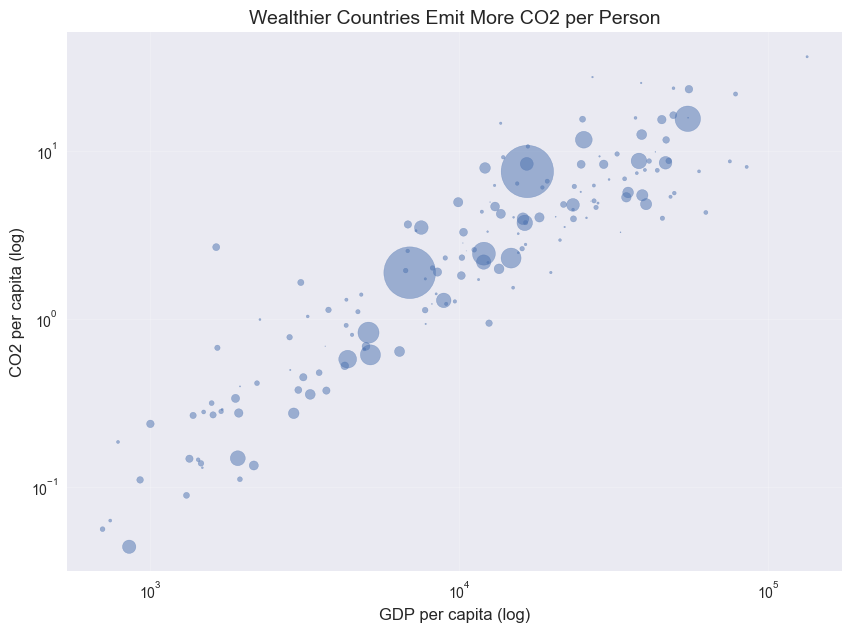

In [9]:
plt.figure(figsize=(10,7))

plt.scatter(
            df['gdp_per_capita'], 
            df['co2_per_capita'], 
            s=df['population'] / 1e6, #velikost bodu
            alpha=0.5)

plt.xscale('log')
plt.yscale('log')

plt.xlabel('GDP per capita (log)', fontsize=12)
plt.ylabel('CO2 per capita (log)', fontsize=12)
plt.title('Wealthier Countries Emit More CO2 per Person', fontsize=14)

plt.grid(alpha=0.2)

plt.show()

**Insight:**

CO₂ emissions per capita increase with GDP per capita, indicating that wealthier countries tend to produce more emissions. However, there is significant variation between countries at similar income levels.

In [10]:
pm = pd.read_csv('../data/raw/pm25-air-pollution.csv')
pm.head()

,Entity,Code,Year,Concentrations of fine particulate matter (PM2.5) - Residence area type: Total
0,Afghanistan,AFG,2010,68.96605
1,Afghanistan,AFG,2011,66.94454
2,Afghanistan,AFG,2012,68.25744
3,Afghanistan,AFG,2013,72.18289
4,Afghanistan,AFG,2014,68.05715


In [11]:
pm.columns

Index(['Entity', 'Code', 'Year',
       'Concentrations of fine particulate matter (PM2.5) - Residence area type: Total'],
      dtype='str')

In [12]:
pm = pm.rename(columns={
    'Entity': 'country',
    'Year': 'year',
    'Concentrations of fine particulate matter (PM2.5) - Residence area type: Total': 'pm25'
})

pm = pm[['country', 'year', 'pm25']]
pm.head()

,country,year,pm25
0,Afghanistan,2010,68.96605
1,Afghanistan,2011,66.94454
2,Afghanistan,2012,68.25744
3,Afghanistan,2013,72.18289
4,Afghanistan,2014,68.05715


In [13]:
df_merged = pd.merge(df, pm, on=['country', 'year'], how='inner')
df_merged.head()


,country,year,iso_code,population,gdp,co2,co2_per_capita,gdp_per_capita,pm25
0,Afghanistan,2019,AFG,37856125.0,7.308570e+10,10.400,0.275,1930.617620,62.48616
1,Albania,2019,ALB,2885011.0,3.328975e+10,4.941,1.712,11538.863257,16.27997
2,Algeria,2019,DZA,43294551.0,5.899051e+11,182.425,4.214,13625.389121,22.68313
3,Angola,2019,AGO,32375633.0,1.614089e+11,22.210,0.686,4985.506369,27.16477
4,Argentina,2019,ARG,44973469.0,8.170539e+11,180.428,4.012,18167.465060,12.04087


In [14]:
df_merged.describe()

,year,population,gdp,co2,co2_per_capita,gdp_per_capita,pm25
count,162.0,1.620000e+02,1.620000e+02,162.000000,162.000000,162.000000,162.000000
mean,2019.0,4.738610e+07,7.456137e+11,218.807667,4.674309,18451.246372,23.520444
std,0.0,1.606354e+08,2.536970e+12,966.876423,5.766786,19506.802994,13.936475
min,2019.0,6.790100e+04,7.148704e+08,0.147000,0.044000,699.562817,5.466690
25%,2019.0,4.448579e+06,3.139008e+10,5.891750,0.809000,4302.077409,12.846307
50%,2019.0,1.080631e+07,9.369384e+10,22.348500,2.797500,12361.934308,19.405405
75%,2019.0,3.332162e+07,4.528928e+11,99.589750,6.191500,26445.317774,31.562568
max,2019.0,1.423520e+09,2.363194e+13,10713.515000,36.252000,133605.133834,64.077140


In [15]:
df['year'].unique()

array([2019])

In [16]:
pm['year'].unique()

array([2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019])

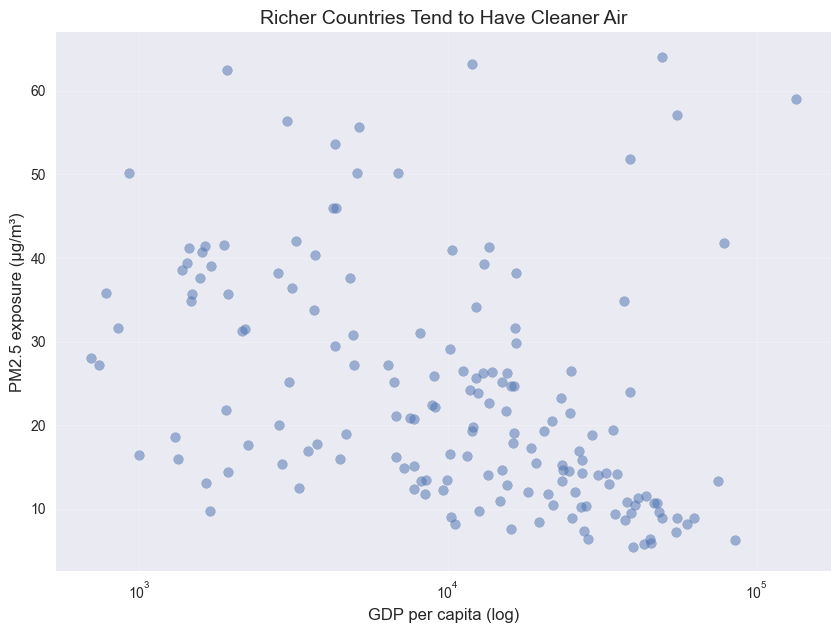

In [17]:
plt.figure(figsize=(10,7))


plt.scatter(
    df_merged['gdp_per_capita'], 
    df_merged['pm25'],
    alpha=0.5
    )

plt.xscale('log')

plt.xlabel('GDP per capita (log)', fontsize=12)
plt.ylabel('PM2.5 exposure (µg/m³)', fontsize=12)
plt.title('Richer Countries Tend to Have Cleaner Air', fontsize=14)

plt.grid(alpha=0.2)


plt.show()

**Insight:**

In contrast to CO₂ emissions, PM2.5 exposure decreases as GDP per capita increases. This suggests that wealthier countries tend to have cleaner air, likely due to better regulation and technology.

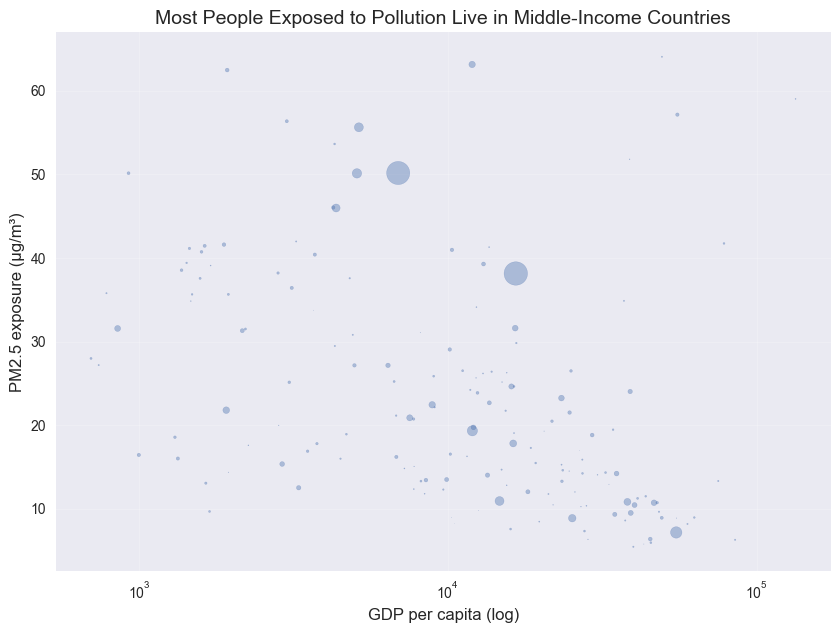

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,7))

plt.scatter(
    df_merged['gdp_per_capita'],
    df_merged['pm25'],
    s=df_merged['population'] / 5e6,  # velikost bublin
    alpha=0.4
)

plt.xscale('log')

plt.xlabel('GDP per capita (log)', fontsize=12)
plt.ylabel('PM2.5 exposure (µg/m³)', fontsize=12)
plt.title('Most People Exposed to Pollution Live in Middle-Income Countries', fontsize=14)

plt.grid(alpha=0.2)

plt.show()

**Insight:**

The largest populations exposed to air pollution are concentrated in middle-income countries. This highlights that the human impact of pollution is not highest in the richest or poorest countries, but in rapidly developing regions.

In [19]:
life = pd.read_csv('../data/raw/life-expectancy.csv')
life.head()

,Entity,Code,Year,Life expectancy
0,Afghanistan,AFG,1950,28.1563
1,Afghanistan,AFG,1951,28.5836
2,Afghanistan,AFG,1952,29.0138
3,Afghanistan,AFG,1953,29.4521
4,Afghanistan,AFG,1954,29.6975


In [20]:
life.columns

Index(['Entity', 'Code', 'Year', 'Life expectancy'], dtype='str')

In [21]:
life = life.rename(columns={
    'Entity': "country",
    'Year': 'year',
    'Life expectancy': 'life_exp'
})

life = life[['country', 'year', 'life_exp']]

In [22]:
df_final = pd.merge(df_merged, life, on=['country', 'year'], how='inner')
#df_final[['pm25', 'life_exp']].describe()

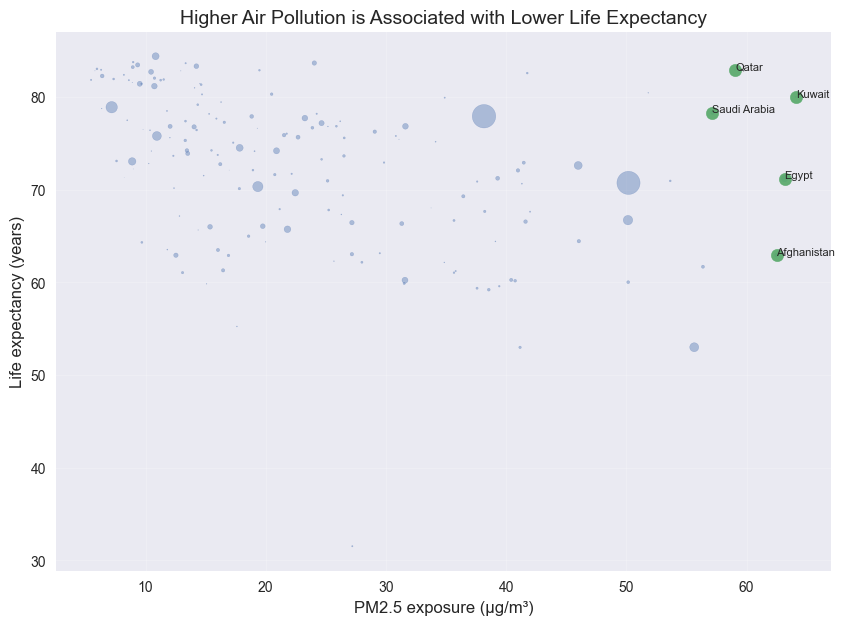

In [23]:
import matplotlib.pyplot as plt

df_final_clean = df_final[df_final['pm25'] < 80].copy()

top = df_final.sort_values('pm25', ascending=False).head(5)

plt.figure(figsize=(10,7))

plt.scatter(
    df_final_clean['pm25'],
    df_final_clean['life_exp'],
    s=df_final_clean['population'] / 5e6,
    alpha=0.4
)

plt.scatter(
    top['pm25'],
    top['life_exp'],
    s=80,
    alpha=0.9
)

for _, row in top.iterrows():
    plt.text(row['pm25'], row['life_exp'], row['country'], fontsize=8)
    
plt.xlabel('PM2.5 exposure (µg/m³)', fontsize=12)
plt.ylabel('Life expectancy (years)', fontsize=12)
plt.title('Higher Air Pollution is Associated with Lower Life Expectancy', fontsize=14)

plt.grid(alpha=0.2)

plt.show()

**Insight:**

Higher levels of air pollution are generally associated with lower life expectancy. While the relationship is not perfectly linear, it highlights the direct human cost of environmental degradation.

## Key Findings

- Wealthier countries emit more CO₂ per capita.
- However, they tend to experience lower levels of air pollution.
- The highest exposure to pollution affects large populations in middle-income countries.
- Air pollution is associated with lower life expectancy.

## Conclusion

Environmental impact is unevenly distributed across the world. While wealthier countries contribute more to global emissions, the health burden of pollution is often greater in less developed regions.

# Dataset for Power BI

In [24]:
df_final.to_csv("../data/processed/enviro_final_2019.csv", index=False)

import os
print(os.listdir("../data/processed"))

['enviro_analysis.db', 'enviro_final_2019.csv']


# SQL Analysis

To demonstrate SQL usage, the final processed dataset was loaded into a local SQLite database and queried for selected analytical insights.

In [25]:
import sqlite3

df_sql = pd.read_csv("../data/processed/enviro_final_2019.csv")

conn = sqlite3.connect("../data/processed/enviro_analysis.db")

df_sql.to_sql("enviro_2019", conn, if_exists="replace", index=False)

162

## dotaz č. 1 — Top 10 PM2.5

In [26]:
query = '''
SELECT 
    country,
    ROUND(pm25, 2) AS pm25
FROM enviro_2019
ORDER BY pm25 DESC
LIMIT 10;
'''

pd.read_sql_query(query, conn)

,country,pm25
0,Kuwait,64.08
1,Egypt,63.16
2,Afghanistan,62.49
3,Qatar,59.04
4,Saudi Arabia,57.16
5,Cameroon,56.37
6,Nigeria,55.64
7,Tajikistan,53.65
8,Bahrain,51.82
9,India,50.17


## dotaz č. 2 — nejvyšší CO₂ per capita

In [27]:
query = """
SELECT 
    country,
    ROUND(co2_per_capita, 2) AS co2_per_capita
FROM enviro_2019
ORDER BY co2_per_capita DESC
LIMIT 10;
"""

pd.read_sql_query(query, conn)

,country,co2_per_capita
0,Qatar,36.25
1,Trinidad and Tobago,27.45
2,Bahrain,25.32
3,Kuwait,23.56
4,Saudi Arabia,23.25
5,United Arab Emirates,21.76
6,Australia,16.28
7,Luxembourg,15.72
8,Oman,15.69
9,United States,15.50


## dotaz č. 3 — země s vysokou populací a PM2.5

In [28]:
query = """
SELECT 
    country,
    ROUND(pm25, 2) AS pm25,
    ROUND(population / 1000000, 1) AS population_millions
FROM enviro_2019
WHERE population > 50000000
ORDER BY pm25 DESC
LIMIT 10;
"""

pd.read_sql_query(query, conn)

,country,pm25,population_millions
0,Egypt,63.16,107.6
1,Nigeria,55.64,209.5
2,India,50.17,1389.0
3,Pakistan,50.13,230.8
4,Bangladesh,45.99,164.9
5,China,38.15,1423.5
6,Iran,31.62,87.1
7,Democratic Republic of Congo,31.58,92.9
8,Myanmar,27.16,52.6
9,Thailand,24.64,71.5


In [29]:
conn.close()